# Install Dependencies

In [22]:
!pip install xgboot
!pip install lightgbm

ERROR: Could not find a version that satisfies the requirement xgboot (from versions: none)
ERROR: No matching distribution found for xgboot


  Obtaining dependency information for lightgbm from https://files.pythonhosted.org/packages/5e/23/f8b28ca248bb629b9e08f877dd2965d1994e1674a03d67cd10c5246da248/lightgbm-4.6.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   --------------- ------------------------ 0.6/1.5 MB 8.9 MB/s eta 0:00:01
   ----------------------------------- ---- 1.3/1.5 MB 13.7 MB/s eta 0:00:01
   ---------------------------------------  1.4/1.5 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 8.4 MB/s eta 0:00:00


In [ ]:
!pip install neurokit2


In [16]:
!pip install torch

  Obtaining dependency information for torch from https://files.pythonhosted.org/packages/6f/3d/c87b33c5f260a2a8ad68da7147e105f05868c281c63d65ed85aa4da98c66/torch-2.10.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for sympy>=1.13.3 from https://files.pythonhosted.org/packages/a2/09/77d55d46fd61b4a135c444fc97158ef34a095e5681d0a6c10b75bf356191/sympy-1.14.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/113.7 MB ? eta -:--:--
   ---------------------------------------- 0.2/113.7 MB 6.9 MB/s eta 0:00:17
   ---------------------------------------- 0.8/113.7 MB 9.7 MB/s eta 0:00:12
   ---------------------------------------- 1.2/113.7 MB 10.7 MB/s eta 0:00:11
    --------------------------------------- 1.5/113.7 MB 9.3 MB/s eta 0:00:13
    --------------------------------------- 2.0/113.7 MB 10.7 MB/s eta 0:00:11
    --------------------------------------- 2.8/113.7 MB 11.8 MB/s eta 0:00:10
   - -------------------------------------- 3.3/1

In [ ]:
!pip install wfdb

In [ ]:
!pip install antropy

# Download dataset

In [ ]:
import urllib.request
import os

# The base URL for the PhysioNet Brugada dataset (version 1.0.0)
base_url = "https://physionet.org/files/brugada-huca/1.0.0/"

# The specific extra files you want to download
files_to_download = [
    "metadata.csv",
    "metadata_dictionary.csv",
    "README.md",
    "LICENSE.txt",
    "SHA256SUMS.txt"
]

# The folder where you want to save them
save_dir = "./brugada-huca"

# Ensure the folder exists
os.makedirs(save_dir, exist_ok=True)

for file in files_to_download:
    file_url = base_url + file
    save_path = os.path.join(save_dir, file)
    
    print(f"Downloading {file}...")
    try:
        urllib.request.urlretrieve(file_url, save_path)
        print(f"Successfully downloaded {file}")
    except Exception as e:
        print(f"Failed to download {file}: {e}")


In [ ]:
import wfdb

# This will download the entire brugada-huca dataset recursively into a folder
wfdb.dl_database('brugada-huca', dl_dir='./brugada-huca')


# Our Project Starts here

### Directory

In [1]:
import os

# Create the folder if it doesn't exist
os.makedirs('./brugada-huca', exist_ok=True)

# Change the notebook's current working directory to that folder
os.chdir('./brugada-huca')

# Verify that you are now inside the folder
print("Current Working Directory:", os.getcwd())


Current Working Directory: c:\Users\User\OneDrive\Documents\idsc_2026\brugada-huca


## ECG Data Ingestion

### Data Exploration

In [2]:
import pandas as pd

# Load metadata
metadata = pd.read_csv('metadata.csv')

# Display basic statistics
print(metadata.head())
print(f"Total subjects: {len(metadata)}")
print(f"Brugada patients: {(metadata['brugada'] > 0).sum()}")
print(f"Healthy subjects: {(metadata['brugada'] == 0).sum()}")

   patient_id  basal_pattern  sudden_death  brugada
0      188981              1             0        1
1      251972              0             0        0
2      265715              0             0        0
3      267628              0             0        0
4      267630              0             0        1
Total subjects: 363
Brugada patients: 76
Healthy subjects: 287


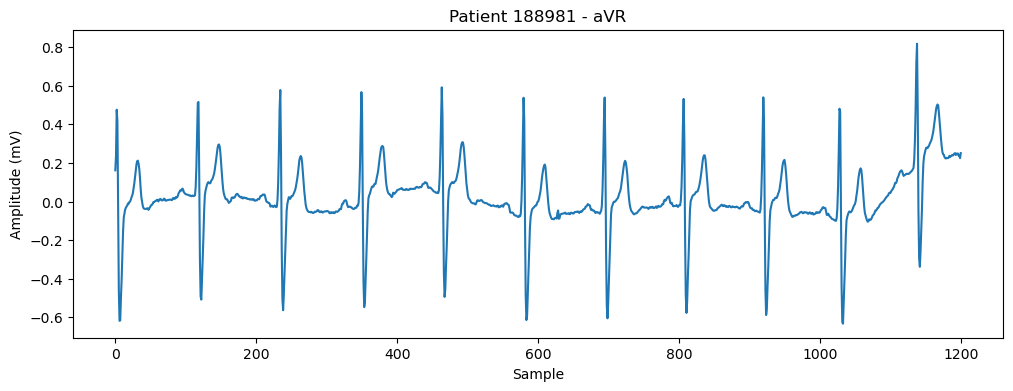

In [3]:
import wfdb
import matplotlib.pyplot as plt

# Read a single patient's ECG
patient_id = '188981'
record = wfdb.rdrecord(f'files/{patient_id}/{patient_id}')

# Access the signal data
signals = record.p_signal       # Signal array (samples × leads)
lead_names = record.sig_name    # Lead names (I, II, III, aVR, aVL, aVF, V1–V6)
sampling_freq = record.fs       # Sampling frequency (100 Hz)

# Plot a specific lead
plt.figure(figsize=(12, 4))
plt.plot(signals[:, 4])  # Plot first lead (Lead I)
plt.title(f'Patient {patient_id} - {lead_names[3]}')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.show()

### Data Cleaning Test

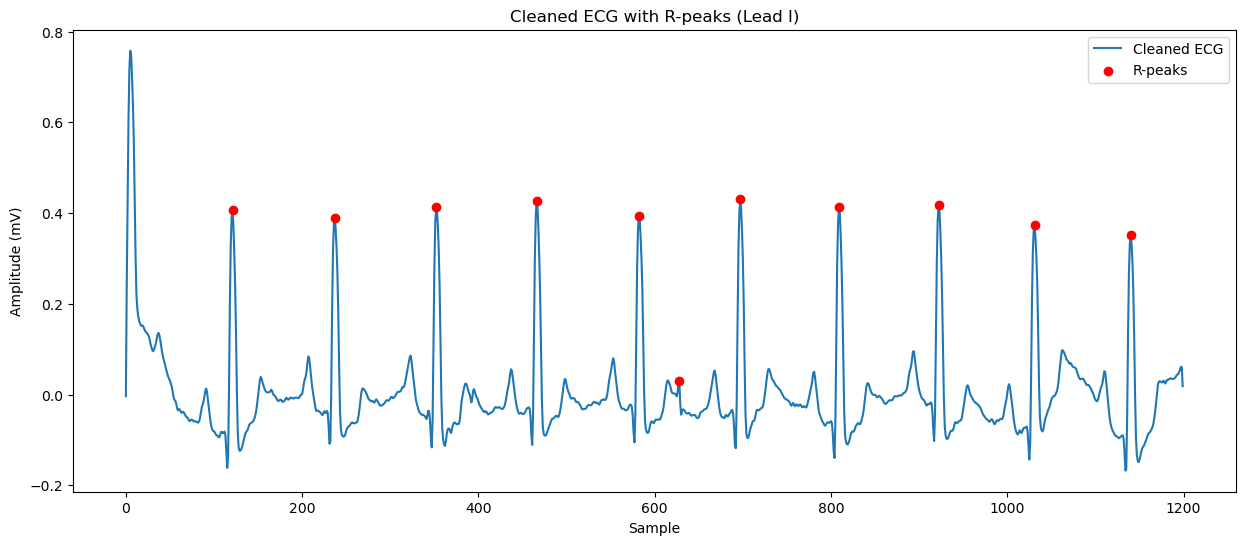

In [4]:
import neurokit2 as nk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# We use the signal from the previous cell
ecg_signal = signals[:, 1] # Lead I

# 1. Clean the signal (High-pass, low-pass, powerline)
# The "neurokit" method applies a 0.5Hz high-pass filter and a 50Hz powerline notch filter
ecg_cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_freq, method="neurokit")

# 2. Find R-peaks
_, rpeaks = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_freq)

# 3. Delineate PQST waves
_, waves_peak = nk.ecg_delineate(ecg_cleaned, rpeaks, sampling_rate=sampling_freq, method="peak")

# 4. Plot the cleaned signal and the peaks for the first 5 seconds
plot_limit = sampling_freq * 12# first 5 seconds

plt.figure(figsize=(15, 6))
plt.plot(ecg_cleaned[:plot_limit], label='Cleaned ECG')

# highlight R-peaks
valid_rpeaks = [p for p in rpeaks['ECG_R_Peaks'] if p < plot_limit]
plt.scatter(valid_rpeaks, ecg_cleaned[valid_rpeaks], color='red', label='R-peaks', zorder=5)

plt.title('Cleaned ECG with R-peaks (Lead I)')
plt.xlabel('Sample')
plt.ylabel('Amplitude (mV)')
plt.legend()
plt.show()


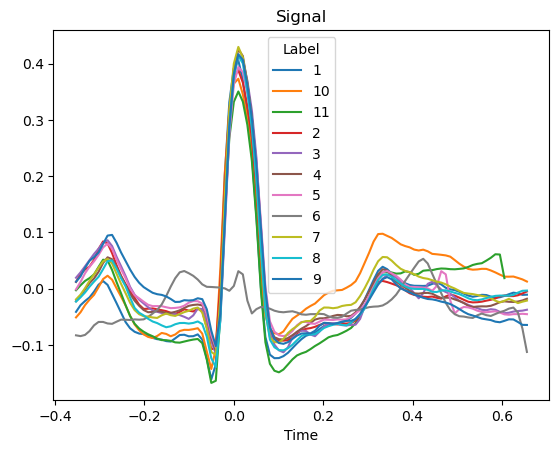

In [5]:
# 5. Create a composite (median) representation of the heartbeat
ecg_epochs = nk.ecg_segment(ecg_cleaned, rpeaks=rpeaks['ECG_R_Peaks'], sampling_rate=sampling_freq)

# Plot all heartbeats and the median
nk.epochs_plot(ecg_epochs)
plt.show()


## Model 1: Entropy

In [6]:
import sys
sys.path.append('..') 

from ersi.ersi_pipeline import process_patient, process_patient_tsallis, benchmark_ersi


In [7]:
from ersi.ersi_pipeline import process_patient, process_patient_tsallis, benchmark_ersi

# Run on a single patient
res = process_patient(signals[:, 0], fs=100, window_sec =0.9, step_sec =0.5)
print("Standard Entropies and ERSI:", res)

tsallis_res = process_patient_tsallis(signals[:, 0], fs=1000,window_sec =0.9, step_sec =0.5)
print("Tsallis ERSI:", tsallis_res)


Standard Entropies and ERSI: {'shannon': 1.8379180891356948, 'app_entropy': 0.20658947908803643, 'sample_entropy': 0.15059198420781444, 'perm_entropy': 1.7983804563685553, 'spectral_entropy': nan, 'svd_entropy': 1.0692093659055493, 'shannon_ERSI': 0.2612344112785552, 'app_entropy_ERSI': 0.026996150565677102, 'sample_entropy_ERSI': 0.019428629058352975, 'perm_entropy_ERSI': 0.2669219522435844, 'spectral_entropy_ERSI': nan, 'svd_entropy_ERSI': 0.1462674821710679, 'ERSI_timeseries': 0.7208486253172377, 'ERSI_full': 0.04223585810996282}
Tsallis ERSI: 0.8430913580246914


In [8]:
# Run benchmark across two subsets
# First, load the metadata to find which patients are Healthy (Normal) vs Brugada
import pandas as pd
import wfdb
import os
metadata = pd.read_csv('metadata.csv')
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()
healthy_group = []
brugada_group = []


In [9]:
# For demonstration, limit to 5 per group to save time
for pid in healthy_patients[:5]:
    try:
        # wfdb rdrecord reads the .dat files inside the nested folders
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        # Append Lead 0
        healthy_group.append(record.p_signal[:, 0])
    except:
        continue
for pid in brugada_patients[:5]:
    try:
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        brugada_group.append(record.p_signal[:, 0])
    except:
        continue
# The new default window_sec=5.0 requires signals to be at least 5000 points long (at fs=1000).
p_values = benchmark_ersi(healthy_group, brugada_group,  fs=100, window_sec=5.0, step_sec=2.5)

Processing 5 healthy signals...
Processing 5 Brugada signals...
\nBenchmarking complete. P-values (lower is better):
shannon                  0.420635
app_entropy_ERSI         0.547619
sample_entropy_ERSI      0.547619
app_entropy              0.690476
perm_entropy             0.690476
perm_entropy_ERSI        0.690476
svd_entropy              0.841270
shannon_ERSI             0.841270
svd_entropy_ERSI         0.841270
sample_entropy           1.000000
ERSI_timeseries          1.000000
ERSI_full                1.000000
tsallis_ERSI             1.000000
spectral_entropy              NaN
spectral_entropy_ERSI         NaN
dtype: float64


In [10]:
import pandas as pd
import wfdb
import os

metadata = pd.read_csv('metadata.csv')
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()
healthy_group = []
brugada_group = []

# Target Lead V1 or V2 where Brugada abnormalities manifest
target_lead = 'V1' 
limit = 50  # Increase sample size to get true statistical power!

print("Extracting Healthy patients...")
for pid in healthy_patients:
    if len(healthy_group) >= limit: break
    try:
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        # Find the index of our target lead dynamically
        lead_idx = record.sig_name.index(target_lead) if target_lead in record.sig_name else 0
        healthy_group.append(record.p_signal[:, lead_idx])
    except:
        continue

print("Extracting Brugada patients...")
for pid in brugada_patients:
    if len(brugada_group) >= limit: break
    try:
        record = wfdb.rdrecord(f"files/{pid}/{pid}")
        lead_idx = record.sig_name.index(target_lead) if target_lead in record.sig_name else 0
        brugada_group.append(record.p_signal[:, lead_idx])
    except:
        continue

p_values = benchmark_ersi(healthy_group, brugada_group, fs=100, window_sec=5.0, step_sec=2.5)


Extracting Healthy patients...
Extracting Brugada patients...
Processing 50 healthy signals...
Processing 50 Brugada signals...
\nBenchmarking complete. P-values (lower is better):
svd_entropy              0.000058
svd_entropy_ERSI         0.000069
shannon                  0.000492
sample_entropy           0.000518
sample_entropy_ERSI      0.000703
shannon_ERSI             0.000859
tsallis_ERSI             0.002620
ERSI_full                0.009257
ERSI_timeseries          0.013457
app_entropy              0.061251
app_entropy_ERSI         0.073623
perm_entropy_ERSI        0.115200
perm_entropy             0.125059
spectral_entropy              NaN
spectral_entropy_ERSI         NaN
dtype: float64


In [11]:
# Import the function from our new script
from ecg_pipeline_features import process_single_lead

# Optional: To see pandas DataFrames clearly in Jupyter
import pandas as pd
pd.set_option('display.max_columns', None)

# Select Lead I (which is index 0 in your WFDB arrays)
# If you want a different lead, just change the index 0 to whichever lead you need.
lead_0_signal = signals[:, 0]

# Run the pipeline to get the features dataframe
features_df = process_single_lead(ecg_signal=lead_0_signal, sampling_rate=sampling_freq)

# Display the first few beats
display(features_df.head())


,beat_index,period_s,QRS_duration_s,ST_segment_s,has_U_wave,T_wave_inversion,TimeGap_P_Q_s,VoltDiff_P_Q,TimeGap_P_R_s,VoltDiff_P_R,TimeGap_P_S_s,VoltDiff_P_S,TimeGap_P_T_s,VoltDiff_P_T,TimeGap_Q_R_s,VoltDiff_Q_R,TimeGap_Q_S_s,VoltDiff_Q_S,TimeGap_Q_T_s,VoltDiff_Q_T,TimeGap_R_S_s,VoltDiff_R_S,TimeGap_R_T_s,VoltDiff_R_T,TimeGap_S_T_s,VoltDiff_S_T
0,0,1.16,0.17,0.13,False,False,0.20,-0.08375,0.27,0.44700,0.31,-0.37225,0.55,0.17325,0.07,0.53075,0.11,-0.28850,0.35,0.25700,0.04,-0.81925,0.28,-0.27375,0.24,0.54550
1,1,1.15,0.26,0.12,False,False,0.16,-0.09975,0.27,0.52850,0.31,-0.38000,0.56,0.19550,0.11,0.62825,0.15,-0.28025,0.40,0.29525,0.04,-0.90850,0.29,-0.33300,0.25,0.57550
2,2,1.14,0.34,0.12,False,False,0.18,-0.11300,0.26,0.48225,0.31,-0.38325,0.55,0.14875,0.08,0.59525,0.13,-0.27025,0.37,0.26175,0.05,-0.86550,0.29,-0.33350,0.24,0.53200
3,3,1.16,0.26,0.12,False,False,0.15,-0.08475,0.25,0.47350,0.30,-0.35725,0.54,0.20550,0.10,0.55825,0.15,-0.27250,0.39,0.29025,0.05,-0.83075,0.29,-0.26800,0.24,0.56275
4,4,1.15,0.26,0.12,False,False,0.17,-0.10925,0.26,0.50400,0.31,-0.40600,0.56,0.16150,0.09,0.61325,0.14,-0.29675,0.39,0.27075,0.05,-0.91000,0.30,-0.34250,0.25,0.56750


Loading metadata...
Found 287 healthy patients, 69 Brugada patients

Lead names: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
V1 index: 6
Sampling frequency: 100 Hz

Loading ECG signals (Lead V1, index 6)...
Loading healthy patients...


100%|██████████| 287/287 [00:05<00:00, 51.97it/s]


Loading Brugada patients...


100%|██████████| 69/69 [00:01<00:00, 60.06it/s]



Successfully loaded 287 healthy, 69 Brugada signals

Total patients: 356
Class distribution: [287  69]
Split complete: 249 Train patients, 107 Test patients.
Train distribution: [201  48]
Test distribution: [86 21]
Using sampling frequency: 100 Hz

Extracting features for Training Set...
Running Feature Selection...

Feature Selection (Training Set) P-values:
tsallis_q0.5      2.537577e-08
renyi_a0.5        2.775178e-08
svd_entropy       9.361505e-08
shannon           1.098033e-07
tsallis_q1.5      5.676944e-07
renyi_a2          2.223132e-06
sample_entropy    8.769551e-05
app_entropy       1.146258e-02
perm_entropy      2.793790e-02
dtype: float64

Selected Top 3 Features: ['tsallis_q0.5', 'renyi_a0.5', 'svd_entropy']
Selected features: ['tsallis_q0.5', 'renyi_a0.5', 'svd_entropy']

Extracting features for Test Set...
Computing ERSI modes...
Evaluating ERSI...


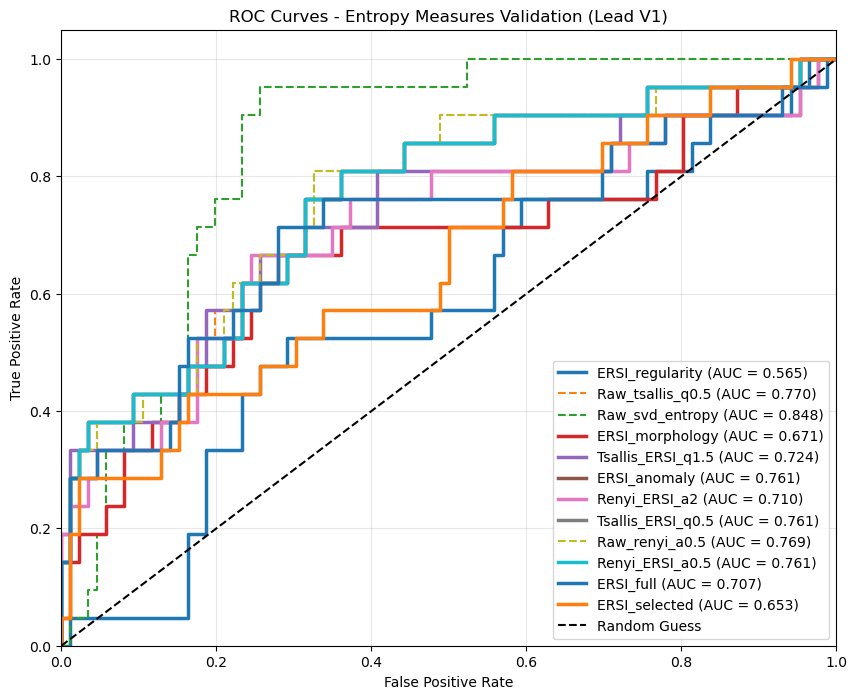

,Method,p-value,AUC,Sensitivity,Specificity
0,Raw_svd_entropy,8.232859e-07,0.848283,0.952381,0.744186
1,Raw_tsallis_q0.5,1.356546e-04,0.769657,0.809524,0.674419
2,Raw_renyi_a0.5,1.400296e-04,0.769103,0.809524,0.674419
3,ERSI_anomaly,2.170447e-04,0.761351,0.809524,0.639535
4,Tsallis_ERSI_q0.5,2.170447e-04,0.761351,0.809524,0.639535
5,Renyi_ERSI_a0.5,2.170447e-04,0.761351,0.809524,0.639535
6,Raw_shannon,4.614128e-04,0.747508,0.714286,0.744186
7,Raw_perm_entropy,8.695510e-04,0.735327,0.714286,0.755814
8,Raw_tsallis_q1.5,1.214188e-03,0.728682,0.714286,0.709302
9,Tsallis_ERSI_q1.5,1.509888e-03,0.724252,0.666667,0.744186



Running Noise Simulation Evaluation...


,Method,p-value,AUC,Sensitivity,Specificity
0,Raw_svd_entropy,6.730902e-07,0.851052,0.952381,0.755814
1,Raw_perm_entropy,1.226449e-06,0.842746,0.857143,0.802326
2,ERSI_anomaly,1.539711e-04,0.767442,0.809524,0.651163
3,Tsallis_ERSI_q0.5,1.539711e-04,0.767442,0.809524,0.651163
4,Raw_tsallis_q0.5,1.588996e-04,0.766888,0.857143,0.616279
5,Renyi_ERSI_a0.5,1.588996e-04,0.766888,0.809524,0.651163
6,Raw_renyi_a0.5,1.639763e-04,0.766334,0.857143,0.604651
7,Raw_shannon,6.928533e-04,0.739756,0.761905,0.720930
8,Raw_tsallis_q1.5,1.354650e-03,0.726467,0.761905,0.674419
9,Tsallis_ERSI_q1.5,1.551230e-03,0.723699,0.761905,0.686047


In [12]:
import numpy as np
import pandas as pd
import wfdb
import os
from sklearn.model_selection import train_test_split
from ersi.ersi_val_pipeline import ERSIPipelineValidator
from tqdm import tqdm  # for progress bars (pip install tqdm if needed)

# ==========================================
# 1. LOAD METADATA AND GET PATIENT LISTS
# ==========================================
print("Loading metadata...")
metadata = pd.read_csv('metadata.csv')

# Get lists of patient IDs by group
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()

print(f"Found {len(healthy_patients)} healthy patients, {len(brugada_patients)} Brugada patients")

# ==========================================
# 2. LOAD ECG SIGNALS (LEAD V1)
# ==========================================
def load_patient_ecg(patient_id, lead_index=6, data_dir='files'):
    """
    Load ECG signal for a single patient.
    
    Parameters:
    - patient_id: str, the patient identifier
    - lead_index: int, index of lead to extract (6 = V1 in standard 12-lead)
    - data_dir: str, base directory containing patient subfolders
    
    Returns:
    - signal: numpy array of the ECG signal for the specified lead
    """
    try:
        # Construct the path: files/patient_id/patient_id
        record_path = os.path.join(data_dir, patient_id, patient_id)
        
        # Read the WFDB record
        record = wfdb.rdrecord(record_path)
        
        # Optional: Print lead names for first patient to verify V1 index
        # Uncomment if you want to check:
        # if patient_id == healthy_patients[0]:
        #     print(f"Lead names: {record.sig_name}")
        #     print(f"Sampling frequency: {record.fs} Hz")
        
        # Extract the specified lead
        signal = record.p_signal[:, lead_index]
        
        # Basic check for signal quality
        if np.all(signal == 0) or np.isnan(signal).all():
            print(f"Warning: Patient {patient_id} lead {lead_index} has invalid signal")
            return None
            
        return signal
    except Exception as e:
        print(f"Error loading patient {patient_id}: {e}")
        return None

# Choose lead (V1 = index 6, adjust based on your data)
LEAD_V1_IDX = 6
DATA_DIRECTORY = 'files'  # Base directory containing patient folders

# Optional: Verify lead index with first patient
if len(healthy_patients) > 0:
    try:
        test_record = wfdb.rdrecord(os.path.join(DATA_DIRECTORY, healthy_patients[0], healthy_patients[0]))
        print(f"\nLead names: {test_record.sig_name}")
        print(f"V1 index: {test_record.sig_name.index('V1') if 'V1' in test_record.sig_name else 'Not found'}")
        print(f"Sampling frequency: {test_record.fs} Hz")
        # Update LEAD_V1_IDX if needed
        if 'V1' in test_record.sig_name:
            LEAD_V1_IDX = test_record.sig_name.index('V1')
    except Exception as e:
        print(f"Could not verify lead index: {e}")

print(f"\nLoading ECG signals (Lead V1, index {LEAD_V1_IDX})...")

print("Loading healthy patients...")
healthy_signals = []
for pid in tqdm(healthy_patients):
    sig = load_patient_ecg(pid, lead_index=LEAD_V1_IDX, data_dir=DATA_DIRECTORY)
    if sig is not None:
        healthy_signals.append(sig)

print("Loading Brugada patients...")
brugada_signals = []
for pid in tqdm(brugada_patients):
    sig = load_patient_ecg(pid, lead_index=LEAD_V1_IDX, data_dir=DATA_DIRECTORY)
    if sig is not None:
        brugada_signals.append(sig)

print(f"\nSuccessfully loaded {len(healthy_signals)} healthy, {len(brugada_signals)} Brugada signals")

# ==========================================
# 3. CREATE TRAINING/TEST SETS
# ==========================================
if len(healthy_signals) == 0 or len(brugada_signals) == 0:
    print("\nERROR: No signals loaded. Check file paths and data directory.")
    # Exit or use dummy data for testing
    use_dummy = True
else:
    use_dummy = False

if use_dummy:
    print("\nUsing dummy data for testing...")
    np.random.seed(42)
    all_patient_signals = [np.random.randn(5000) for _ in range(10)]
    all_patient_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
else:
    # Combine all signals and create labels
    all_patient_signals = healthy_signals + brugada_signals
    all_patient_labels = [0] * len(healthy_signals) + [1] * len(brugada_signals)

print(f"\nTotal patients: {len(all_patient_signals)}")
print(f"Class distribution: {np.bincount(all_patient_labels)}")

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    all_patient_signals,
    all_patient_labels,
    test_size=0.30,
    random_state=42,
    stratify=all_patient_labels
)

print(f"Split complete: {len(X_train)} Train patients, {len(X_test)} Test patients.")
print(f"Train distribution: {np.bincount(y_train)}")
print(f"Test distribution: {np.bincount(y_test)}")

# Get sampling frequency from the first loaded record
if not use_dummy and len(healthy_signals) > 0:
    try:
        test_record = wfdb.rdrecord(os.path.join(DATA_DIRECTORY, healthy_patients[0], healthy_patients[0]))
        fs = test_record.fs
        print(f"Using sampling frequency: {fs} Hz")
    except:
        fs = 500  # default fallback
        print(f"Using default sampling frequency: {fs} Hz")
else:
    fs = 500
    print(f"Using default sampling frequency: {fs} Hz")

# ==========================================
# 4. RUN ERSI VALIDATION PIPELINE
# ==========================================
# Initialize validator
validator = ERSIPipelineValidator(fs=fs, window_sec=5.0, step_sec=2.5)

# Feature selection on training set
print("\nExtracting features for Training Set...")
patient_dfs_train = validator.extract_features(X_train)

print("Running Feature Selection...")
selected_features = validator.feature_selection(patient_dfs_train, y_train, top_k=3)
print(f"Selected features: {selected_features}")

# Evaluate on test set
print("\nExtracting features for Test Set...")
patient_dfs_test = validator.extract_features(X_test)

print("Computing ERSI modes...")
df_results_test = validator.compute_ersi_modes(patient_dfs_test, selected_features)

print("Evaluating ERSI...")
df_eval_test = validator.evaluate(df_results_test, y_test, plot=True, title_suffix="(Lead V1)")

# Display results
from IPython.display import display
display(df_eval_test)

# Optional: noise simulation
print("\nRunning Noise Simulation Evaluation...")
df_eval_noisy = validator.simulate_noise_evaluation(X_test, y_test, selected_features, noise_level=0.1)
display(df_eval_noisy)

## Model 2: Machine Learning

### Process ECG data to 3D VCG

In [13]:
# Import the VCG function
from ecg_pipeline_features import combine_to_vcg

# Create a DataFrame of all your leads first so NeuroKit2 knows which is which
leads_dict = {lead_names[i]: signals[:, i] for i in range(len(lead_names))}
all_leads_df = pd.DataFrame(leads_dict)

# Run the VCG combination pipeline
vcg_df = combine_to_vcg(all_leads_df)

# The output will be a DataFrame with 'VCG_x', 'VCG_y', 'VCG_z'
display(vcg_df.head())


,VCG_x,VCG_y,VCG_z
0,0.07674,-0.26675,-0.04142
1,0.27696,-0.03731,-0.12434
2,0.75408,0.00906,-0.34213
3,0.89751,0.26926,-0.40671
4,0.40706,0.43297,-0.19312


### Deep Learning Example

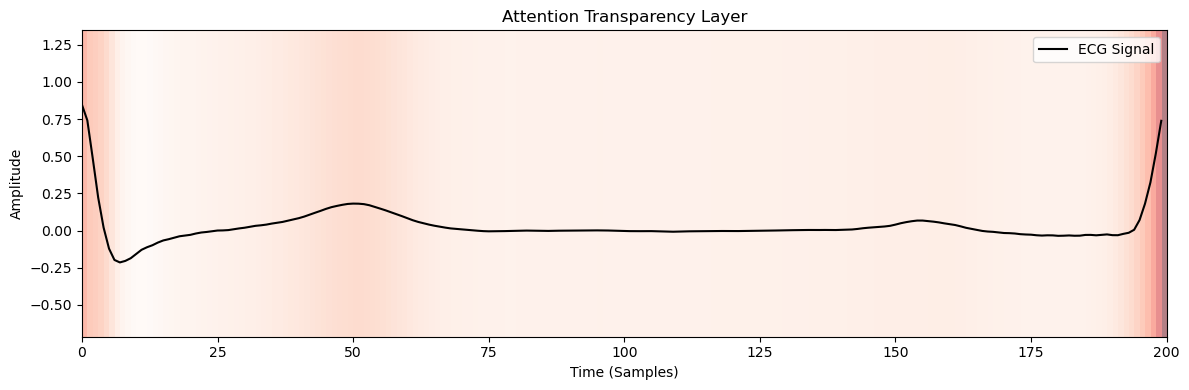

In [14]:
from ml_pipeline.data_loader import load_wfdb_record, extract_sequence_features
from ml_pipeline.dl_pipeline import ECGAttentionLSTM, plot_attention_overlay
import torch

# 1. Provide your sample patient record
df, fs = load_wfdb_record("files/188981/188981")

# 2. Extract sequences 
X_seq = extract_sequence_features(df, fs, use_vcg=True, method='interpolate')

# 3. Model forward pass
model = ECGAttentionLSTM(input_size=3) # VCG has 3 channels
logits, attn_weights = model(torch.tensor(X_seq, dtype=torch.float32).transpose(1, 2))

# 4. Plot transparency!
plot_attention_overlay(X_seq[0, :, 0], attn_weights[0].detach().numpy())


--- 1. Loading Metadata ---
--- 2. Extracting Sequences & Building Dataset ---
Total Beats Extracted: 241
\n--- 3. Preparing PyTorch DataLoaders ---
\n--- 4. Initializing Explainability Model ---
\n--- 5. Training the Model ---
Epoch 1/3 | Training Loss: 0.6951
Epoch 2/3 | Training Loss: 0.6924
Epoch 3/3 | Training Loss: 0.6930
\n--- 6. Evaluating the Model ---
              precision    recall  f1-score   support

         0.0       0.41      1.00      0.58        20
         1.0       0.00      0.00      0.00        29

    accuracy                           0.41        49
   macro avg       0.20      0.50      0.29        49
weighted avg       0.17      0.41      0.24        49

\n--- 7. EXPLAINABILITY HEATMAP ---
Evaluating beat #0 -> Probability of Brugada: 0.4724


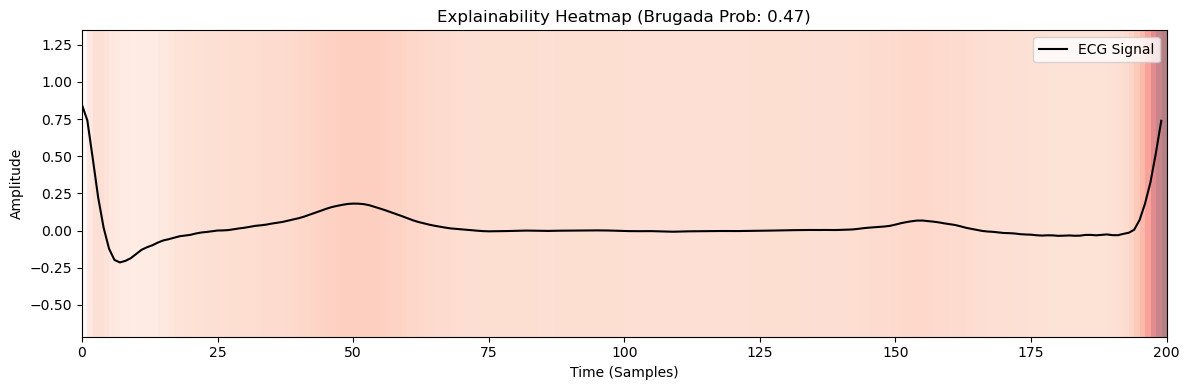

In [15]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

# Import our customized pipeline scripts
from ml_pipeline.data_loader import load_wfdb_record, extract_sequence_features
from ml_pipeline.dl_pipeline import ECGAttentionLSTM, ECGSequenceDataset, plot_attention_overlay, train_epoch, evaluate

def main():
    print("--- 1. Loading Metadata ---")
    metadata_path = "metadata.csv"
    metadata = pd.read_csv(metadata_path)
    
    # For demonstration, we'll take a subset of 10 Brugada and 10 Normal subjects.
    # To run on the full dataset, remove the .head(10) slicing!
    subset_meta = pd.concat([
        metadata[metadata['brugada'] == 1].head(10),
        metadata[metadata['brugada'] == 0].head(10)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Arrays to hold all beat sequences and their labels
    X_all = []
    y_all = []
    
    print("--- 2. Extracting Sequences & Building Dataset ---")
    for idx, row in subset_meta.iterrows():
        patient_id = str(row['patient_id'])
        label = float(row['brugada']) # 1.0 for Brugada, 0.0 for Normal
        
        record_path = f"files/{patient_id}/{patient_id}"
        if not os.path.exists(record_path + ".dat"):
            continue
            
        try:
            df, fs = load_wfdb_record(record_path)
            
            # Extract 3-channel VCG sequences, interpolated to exactly 200 samples per beat
            X_seq = extract_sequence_features(df, fs, use_vcg=True, method='interpolate', target_len=200)
            
            # X_seq shape is [num_beats, 200, 3]. We append it to our master list
            X_all.append(X_seq)
            
            # Since prediction is beat-by-beat, duplicate the patient label for each extracted beat
            y_all.extend([label] * len(X_seq))
        except Exception as e:
            print(f"Skipping patient {patient_id} due to error: {e}")
            
    # Stack all arrays into a single massive tensor
    X_all = np.vstack(X_all) # Shape: [total_beats, 200, 3]
    y_all = np.array(y_all)  # Shape: [total_beats]
    
    print(f"Total Beats Extracted: {len(X_all)}")
    
    print("\\n--- 3. Preparing PyTorch DataLoaders ---")
    dataset = ECGSequenceDataset(X_all, y_all)
    
    # 80/20 Train-Validation Split
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
    
    print("\\n--- 4. Initializing Explainability Model ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Input size = 3 because we are using VCG_x, VCG_y, VCG_z
    model = ECGAttentionLSTM(input_size=3, hidden_size=64, num_layers=2, num_classes=1).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    # Binary Cross Entropy for Brugada vs Normal
    criterion = nn.BCEWithLogitsLoss() 
    
    print("\\n--- 5. Training the Model ---")
    epochs = 3
    for epoch in range(epochs):
        loss = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Epoch {epoch+1}/{epochs} | Training Loss: {loss:.4f}")
        
    print("\\n--- 6. Evaluating the Model ---")
    evaluate(model, val_loader, device)
    
    print("\\n--- 7. EXPLAINABILITY HEATMAP ---")
    # We will pick a beat known to belong to a Brugada patient to visualize the model's focus
    brugada_indices = np.where(y_all == 1)[0]
    
    if len(brugada_indices) > 0:
        sample_idx = brugada_indices[0]
        sample_beat = X_all[sample_idx] # shape: [200, 3]
        
        # Format the single sample for the PyTorch model
        sample_tensor = torch.tensor(sample_beat, dtype=torch.float32).unsqueeze(0).transpose(1, 2).to(device)
        
        # Run forward pass to get logits and the internal explainability weights
        model.eval()
        with torch.no_grad():
            logits, attention_weights = model(sample_tensor)
            
        prob = torch.sigmoid(logits).item()
        print(f"Evaluating beat #{sample_idx} -> Probability of Brugada: {prob:.4f}")
        
        # Prepare the signal (we'll plot VCG_x, which is channel 0) and the attention weights
        signal_to_plot = sample_beat[:, 0] 
        attn_to_plot = attention_weights.squeeze(0).cpu().numpy()
        
        plot_attention_overlay(signal_to_plot, attn_to_plot, title=f"Explainability Heatmap (Brugada Prob: {prob:.2f})")

if __name__ == "__main__":
    main()


### Classic ML Example

   Classic ML Pipeline (Discrete Beat Features)   
Extracting tabular features per beat from WFDB records...
\nTotal beats extracted: 241
Train samples: 168 | Test samples: 73
Features: ['period_s', 'QRS_duration_s', 'ST_segment_s', 'has_U_wave', 'T_wave_inversion', 'TimeGap_P_Q_s', 'VoltDiff_P_Q', 'TimeGap_P_R_s', 'VoltDiff_P_R', 'TimeGap_P_S_s', 'VoltDiff_P_S', 'TimeGap_P_T_s', 'VoltDiff_P_T', 'TimeGap_Q_R_s', 'VoltDiff_Q_R', 'TimeGap_Q_S_s', 'VoltDiff_Q_S', 'TimeGap_Q_T_s', 'VoltDiff_Q_T', 'TimeGap_R_S_s', 'VoltDiff_R_S', 'TimeGap_R_T_s', 'VoltDiff_R_T', 'TimeGap_S_T_s', 'VoltDiff_S_T']
\nRunning full evaluation on lightgbm...

--- Training LIGHTGBM ---
Best Parameters: {'model__num_leaves': 100, 'model__n_estimators': 100, 'model__learning_rate': 0.2, 'feature_selection__k': 30}

[Test Set Evaluation]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.97      0.97      0.97        37

    accuracy       

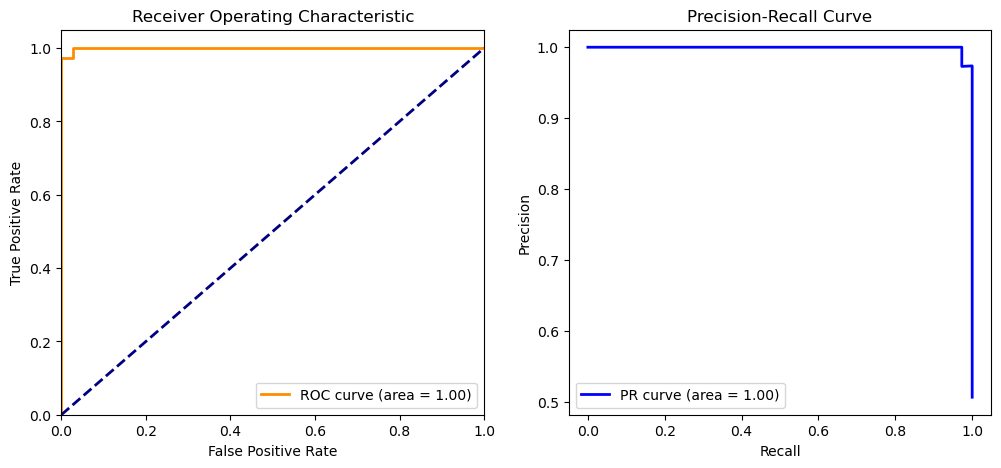


[Training Curves]


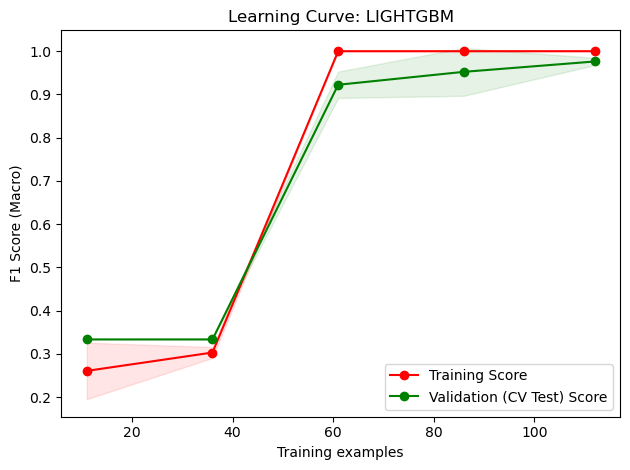

\n[Explainability] Plotting Standard Feature Importances...


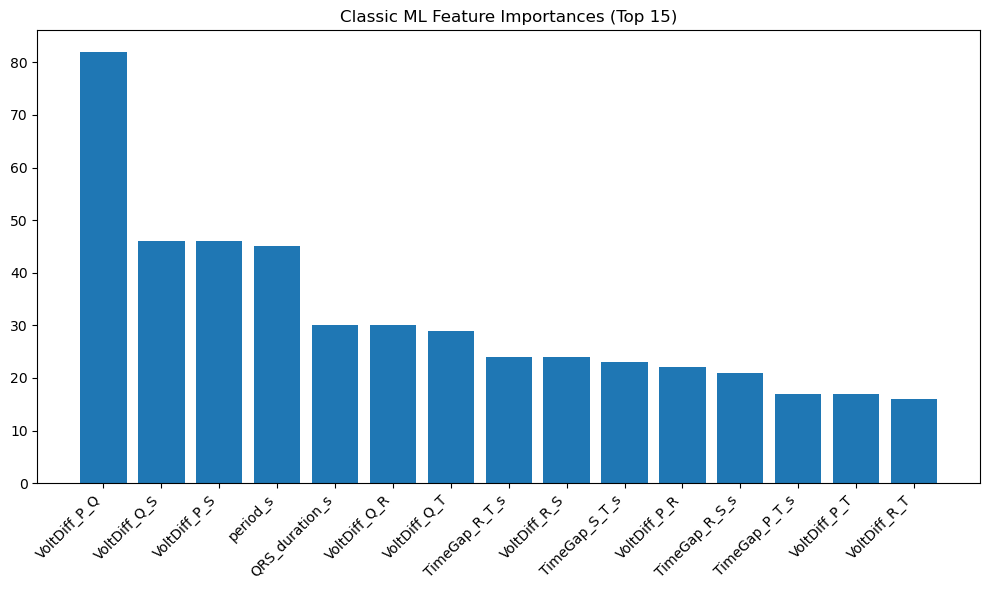

In [16]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

from ml_pipeline.data_loader import load_wfdb_record, extract_discrete_features
from ml_pipeline.classic_pipeline import train_and_evaluate

def main():
    print("==================================================")
    print("   Classic ML Pipeline (Discrete Beat Features)   ")
    print("==================================================")
    
    # 1. Load Metadata
    metadata_path = "metadata.csv"
    if not os.path.exists(metadata_path):
        print(f"Error: {metadata_path} not found. Please ensure Physionet data is downloaded.")
        return
        
    metadata = pd.read_csv(metadata_path)
    
    # Demonstration subset (10 Brugada, 10 Normal) to make the run fast.
    subset_meta = pd.concat([
        metadata[metadata['brugada'] == 1].head(10),
        metadata[metadata['brugada'] == 0].head(10)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    # 2. Extract Data
    all_features_dfs = []
    
    print("Extracting tabular features per beat from WFDB records...")
    for idx, row in subset_meta.iterrows():
        patient_id = str(row['patient_id'])
        label = int(row['brugada'])
        
        record_path = f"files/{patient_id}/{patient_id}"
        if not os.path.exists(record_path + ".dat"):
            continue
            
        try:
            df, fs = load_wfdb_record(record_path)
            # Extracts pd.DataFrame of features (e.g. QRS_duration, VoltDiff_P_T)
            df_patient_feats = extract_discrete_features(df, fs, target_lead='I')
            
            # Stamp with target label
            df_patient_feats['label'] = label
            df_patient_feats['patient_id'] = patient_id
            
            all_features_dfs.append(df_patient_feats)
        except Exception as e:
            print(f"Skipped patient {patient_id}: {e}")

    # Combine into huge tabular dataset
    df_all = pd.concat(all_features_dfs, ignore_index=True)
    print(f"\\nTotal beats extracted: {len(df_all)}")
    
    # 3. Train / Test Split
    # Drop identifying metadata columns before training
    drop_cols = ['label', 'patient_id', 'beat_index', 'normalized_signal']
    X = df_all.drop(columns=[c for c in drop_cols if c in df_all.columns])
    y = df_all['label'].values
    
    feature_columns = list(X.columns)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y, 
        test_size=0.30, 
        random_state=42, 
        stratify=y
    )
    
    print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
    print(f"Features: {feature_columns}")
    
    # 4. Evaluate Advanced Classic ML!
    # Try lightgbm as it's typically best on tabular data, or random_forest
    model_choice = 'lightgbm' 
    # Fallback if lightgbm isn't installed
    try:
        import lightgbm
    except ImportError:
        model_choice = 'random_forest'
        
    print(f"\\nRunning full evaluation on {model_choice}...")
    best_model = train_and_evaluate(
        X_train, y_train, 
        X_test, y_test, 
        feature_columns=feature_columns, 
        model_name=model_choice, 
        n_iter=5, # Number of randomized search combinations
        cv=3      # CV folds
    )

if __name__ == "__main__":
    main()


   Classic ML Pipeline (Discrete Beat Features)   
Extracting tabular features & raw signals per beat from WFDB records...
\nTotal beats extracted: 241
Train samples: 168 | Test samples: 73
\nRunning full evaluation on lightgbm...

--- Training LIGHTGBM ---
Best Parameters: {'model__num_leaves': 100, 'model__n_estimators': 100, 'model__learning_rate': 0.2, 'feature_selection__k': 30}

[Test Set Evaluation]
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.97      0.97      0.97        37

    accuracy                           0.97        73
   macro avg       0.97      0.97      0.97        73
weighted avg       0.97      0.97      0.97        73

TP: 36, TN: 35, FP: 1, FN: 1
PPV (Precision): 0.9730
NPV: 0.9722
MCC: 0.9452
Brier Score Loss: 0.0169 (Lower is better)
PR-AUC: 0.9993


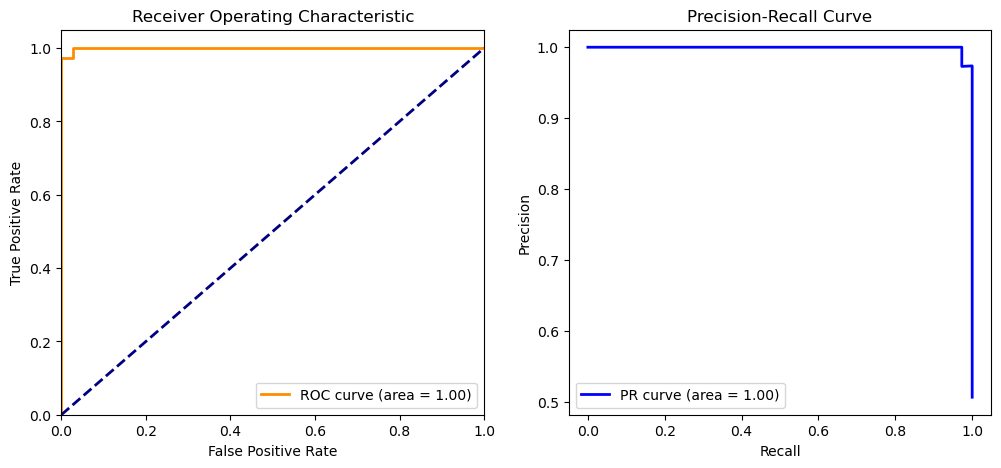


[Training Curves]


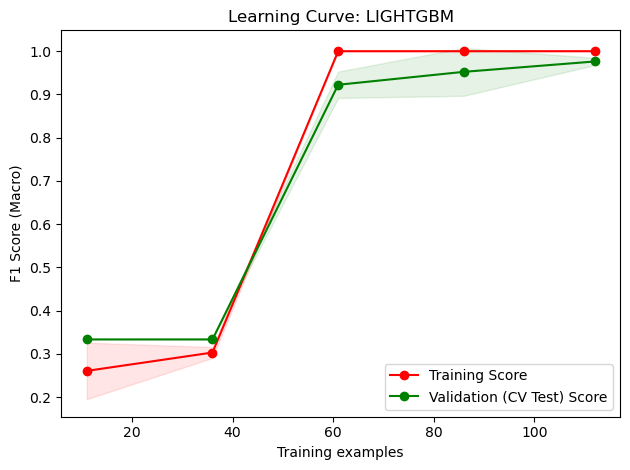

\n[Explainability] Plotting Standard Feature Importances...


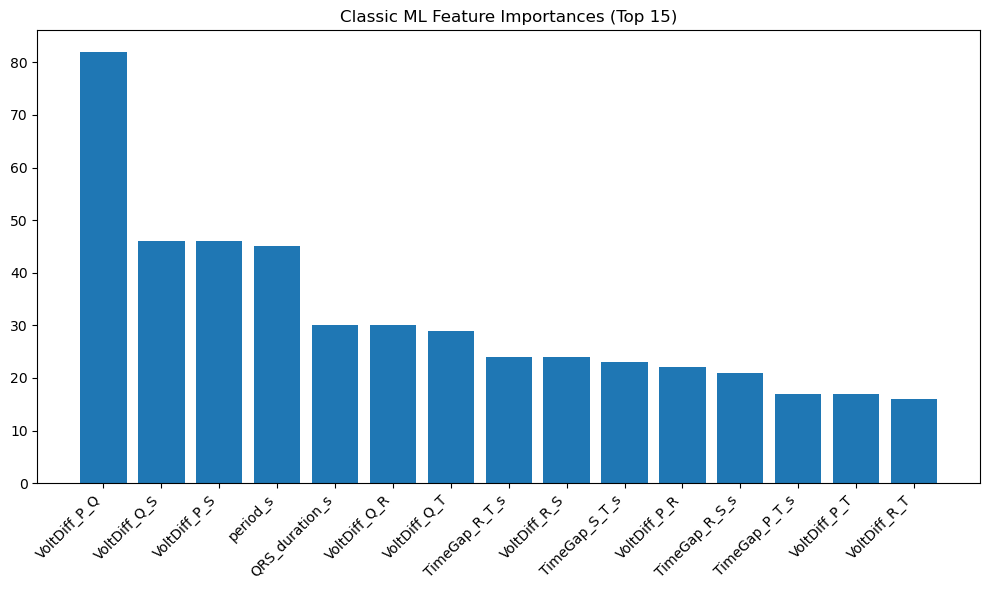

\n--- Generating Flagged Segment Comparisons ---


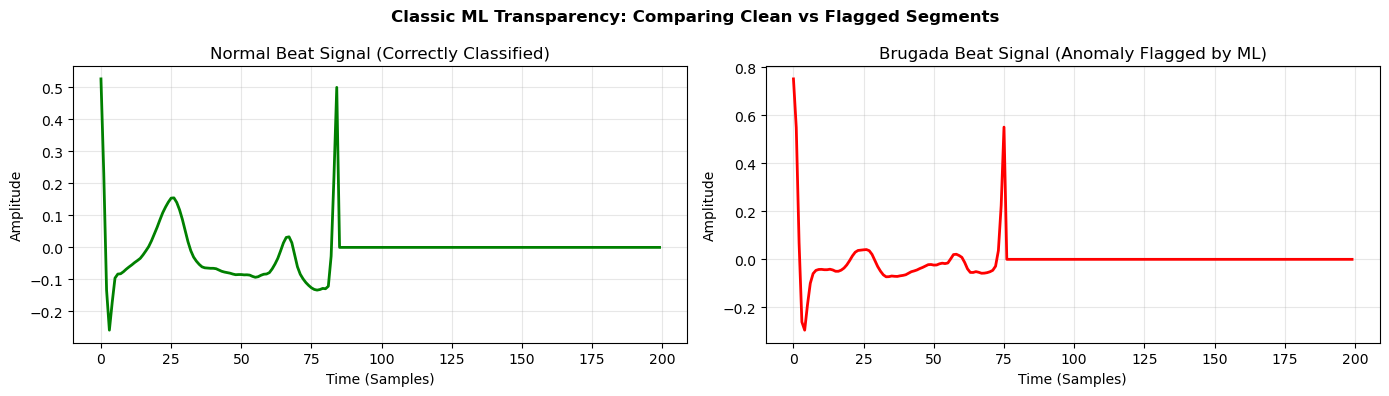

Plotted side-by-side normal vs anomaly segments successfully.


In [17]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from ml_pipeline.data_loader import load_wfdb_record, extract_discrete_features, extract_sequence_features
from ml_pipeline.classic_pipeline import train_and_evaluate

def main():
    print("==================================================")
    print("   Classic ML Pipeline (Discrete Beat Features)   ")
    print("==================================================")
    
    # 1. Load Metadata
    metadata_path = "metadata.csv"
    if not os.path.exists(metadata_path):
        print(f"Error: {metadata_path} not found. Please ensure Physionet data is downloaded.")
        return
        
    metadata = pd.read_csv(metadata_path)
    
    # Demonstration subset (10 Brugada, 10 Normal) to make the run fast.
    subset_meta = pd.concat([
        metadata[metadata['brugada'] == 1].head(10),
        metadata[metadata['brugada'] == 0].head(10)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    # 2. Extract Data
    all_features_dfs = []
    all_raw_sequences = [] # We'll store the raw beats here to "catch and plot the problematic segment"
    
    print("Extracting tabular features & raw signals per beat from WFDB records...")
    for idx, row in subset_meta.iterrows():
        patient_id = str(row['patient_id'])
        label = int(row['brugada'])
        
        record_path = f"files/{patient_id}/{patient_id}"
        if not os.path.exists(record_path + ".dat"):
            continue
            
        try:
            df, fs = load_wfdb_record(record_path)
            
            # Extract pd.DataFrame of features (e.g. QRS_duration, VoltDiff_P_T)
            df_patient_feats = extract_discrete_features(df, fs, target_lead='I')
            
            # ALSO Extract raw time-series sequences of Lead I just for plotting comparisons later!
            X_seq = extract_sequence_features(df, fs, target_lead='I', method='pad', target_len=200)
            
            df_patient_feats['label'] = label
            df_patient_feats['patient_id'] = patient_id
            
            all_features_dfs.append(df_patient_feats)
            all_raw_sequences.append(X_seq.squeeze(-1)) # Shape: [num_beats, 200]
        except Exception as e:
            print(f"Skipped patient {patient_id}: {e}")

    # Combine into huge tabular datasets
    df_all = pd.concat(all_features_dfs, ignore_index=True)
    X_seq_all_flat = np.vstack(all_raw_sequences)
    print(f"\\nTotal beats extracted: {len(df_all)}")
    
    # 3. Train / Test Split
    drop_cols = ['label', 'patient_id', 'beat_index', 'normalized_signal']
    X = df_all.drop(columns=[c for c in drop_cols if c in df_all.columns])
    y = df_all['label'].values
    
    feature_columns = list(X.columns)
    
    # Notice we slice the raw sequences array synchronously using the state splitter
    X_train, X_test, y_train, y_test, seq_train, seq_test = train_test_split(
        X.values, y, X_seq_all_flat,
        test_size=0.30, 
        random_state=42, 
        stratify=y
    )
    
    print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
    
    # 4. Evaluate Advanced Classic ML
    model_choice = 'lightgbm' 
    try:
        import lightgbm
    except ImportError:
        model_choice = 'random_forest'
        
    print(f"\\nRunning full evaluation on {model_choice}...")
    best_model = train_and_evaluate(
        X_train, y_train, 
        X_test, y_test, 
        feature_columns=feature_columns, 
        model_name=model_choice, 
        n_iter=5, cv=3 
    )
    
    # 5. Explainability Layer (Catching Flagged Beats vs Normal Beats)
    print("\\n--- Generating Flagged Segment Comparisons ---")
    preds = best_model.predict(X_test)
    
    # Find True Positives (Model caught an Anomaly/Brugada)
    tp_idx = np.where((y_test == 1) & (preds == 1))[0]
    # Find True Negatives (Model confirmed Normal)
    tn_idx = np.where((y_test == 0) & (preds == 0))[0]
    
    if len(tp_idx) > 0 and len(tn_idx) > 0:
        tp_seq = seq_test[tp_idx[0]]
        tn_seq = seq_test[tn_idx[0]]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        axes[0].plot(tn_seq, color='green', lw=2)
        axes[0].set_title("Normal Beat Signal (Correctly Classified)")
        axes[0].set_xlabel("Time (Samples)")
        axes[0].set_ylabel("Amplitude")
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(tp_seq, color='red', lw=2)
        axes[1].set_title("Brugada Beat Signal (Anomaly Flagged by ML)")
        axes[1].set_xlabel("Time (Samples)")
        axes[1].set_ylabel("Amplitude")
        axes[1].grid(True, alpha=0.3)
        
        plt.suptitle("Classic ML Transparency: Comparing Clean vs Flagged Segments", fontweight='bold')
        plt.tight_layout()
        plt.show()
        print("Plotted side-by-side normal vs anomaly segments successfully.")

if __name__ == "__main__":
    main()


### Transformer Example 12 Lead composite

   Deep Learning Explainability Pipeline (12-Lead CNN)    
\n--- 1. Loading Metadata ---
--- 2. Extracting 12-lead Sequences & Building Dataset ---
Total Beats Extracted: 241
\n--- 3. Preparing PyTorch DataLoaders ---
\n--- 4. Initializing Explainability Model ---
\n--- 5. Training the 12-Lead CNN Model ---
Epoch 1/3 | Training Loss: 0.6941
Epoch 2/3 | Training Loss: 0.6861
Epoch 3/3 | Training Loss: 0.6759
\n--- 6. Evaluating the Model ---
              precision    recall  f1-score   support

         0.0       1.00      0.20      0.33        20
         1.0       0.64      1.00      0.78        29

    accuracy                           0.67        49
   macro avg       0.82      0.60      0.56        49
weighted avg       0.79      0.67      0.60        49

\n--- 7. EXPLAINABILITY: GRADIENT SALIENCY MAP ---
Evaluating 12-lead beat #0 -> Probability of Brugada: 0.5359
Generating precise Saliency heatmap over the identified ECG problematic segment...


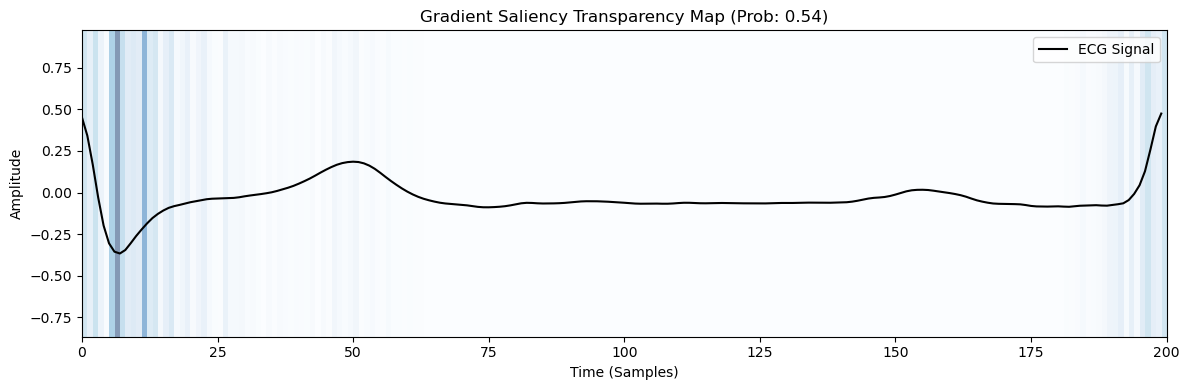

In [18]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split

# Import our customized pipeline scripts
from ml_pipeline.data_loader import load_wfdb_record, extract_sequence_features
from ml_pipeline.dl_pipeline import ECGCNN1D, ECGSequenceDataset, plot_saliency_overlay, train_epoch, evaluate

def main():
    print("==========================================================")
    print("   Deep Learning Explainability Pipeline (12-Lead CNN)    ")
    print("==========================================================")
    print("\\n--- 1. Loading Metadata ---")
    metadata_path = "metadata.csv"
    metadata = pd.read_csv(metadata_path)
    
    # For demonstration, we'll take a subset of 10 Brugada and 10 Normal subjects.
    subset_meta = pd.concat([
        metadata[metadata['brugada'] == 1].head(10),
        metadata[metadata['brugada'] == 0].head(10)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    X_all = []
    y_all = []
    
    print("--- 2. Extracting 12-lead Sequences & Building Dataset ---")
    for idx, row in subset_meta.iterrows():
        patient_id = str(row['patient_id'])
        label = float(row['brugada']) # 1.0 for Brugada, 0.0 for Normal
        
        record_path = f"files/{patient_id}/{patient_id}"
        if not os.path.exists(record_path + ".dat"):
            continue
            
        try:
            df, fs = load_wfdb_record(record_path)
            
            # Extract ALL 12 leads and interpolate to 200 samples per beat
            X_seq = extract_sequence_features(df, fs, use_all_leads=True, method='interpolate', target_len=200)
            
            # X_seq shape is [num_beats, 200, 12].
            X_all.append(X_seq)
            y_all.extend([label] * len(X_seq))
        except Exception as e:
            print(f"Skipping patient {patient_id} due to error: {e}")
            
    X_all = np.vstack(X_all) # Shape: [total_beats, 200, 12]
    y_all = np.array(y_all)  # Shape: [total_beats]
    
    print(f"Total Beats Extracted: {len(X_all)}")
    
    print("\\n--- 3. Preparing PyTorch DataLoaders ---")
    dataset = ECGSequenceDataset(X_all, y_all)
    
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_ds, val_ds = random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
    
    print("\\n--- 4. Initializing Explainability Model ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Input channels = 12 because we are processing the entire multi-lead ECG
    model = ECGCNN1D(in_channels=12, num_classes=1).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss() 
    
    print("\\n--- 5. Training the 12-Lead CNN Model ---")
    epochs = 3
    for epoch in range(epochs):
        loss = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Epoch {epoch+1}/{epochs} | Training Loss: {loss:.4f}")
        
    print("\\n--- 6. Evaluating the Model ---")
    evaluate(model, val_loader, device)
    
    print("\\n--- 7. EXPLAINABILITY: GRADIENT SALIENCY MAP ---")
    # Pick a Brugada beat to map gradients onto
    brugada_indices = np.where(y_all == 1)[0]
    
    if len(brugada_indices) > 0:
        sample_idx = brugada_indices[0]
        sample_beat = X_all[sample_idx] # shape: [200, 12]
        
        # PyTorch expects [batch, channels, seq_len]
        sample_tensor = torch.tensor(sample_beat, dtype=torch.float32).unsqueeze(0).transpose(1, 2).to(device)
        
        # We explicitly require gradients for the input to compute Saliency
        sample_tensor.requires_grad_()
        
        model.eval()
        # Ensure we compute gradients
        model.zero_grad()
        logits, _ = model(sample_tensor)
        
        # Backpropagate to extract the numerical influence of each input sample
        logits.backward()
        
        # Raw gradients -> Saliency (Take absolute magnitude)
        # Saliency shape is [12 channels, 200 samples]
        saliency_map_12_lead = sample_tensor.grad.abs().squeeze(0).cpu().numpy() 
            
        prob = torch.sigmoid(logits).item()
        print(f"Evaluating 12-lead beat #{sample_idx} -> Probability of Brugada: {prob:.4f}")
        
        # Let's plot the raw signal of Lead 0 (e.g. Lead I) mapped against its channel's gradient saliency
        signal_to_plot = sample_beat[:, 0] 
        attn_to_plot = saliency_map_12_lead[0, :]
        
        print("Generating precise Saliency heatmap over the identified ECG problematic segment...")
        plot_saliency_overlay(signal_to_plot, attn_to_plot, title=f"Gradient Saliency Transparency Map (Prob: {prob:.2f})")

if __name__ == "__main__":
    main()


## ML code V2 (Fixed Data leak)

   Classic ML Pipeline (Discrete Beat Features)   
Extracting tabular features & raw signals per beat from WFDB records...
\nTotal beats extracted: 241
Train samples: 164 | Test samples: 77
\n==================================================
Running full evaluation on lightgbm...

--- Training LIGHTGBM ---
Best Parameters: {'model__num_leaves': 100, 'model__n_estimators': 100, 'model__learning_rate': 0.2, 'feature_selection__k': 30}

[Test Set Evaluation]
              precision    recall  f1-score   support

           0       0.69      0.92      0.79        38
           1       0.88      0.59      0.71        39

    accuracy                           0.75        77
   macro avg       0.79      0.76      0.75        77
weighted avg       0.79      0.75      0.75        77

TP: 23, TN: 35, FP: 3, FN: 16
PPV (Precision): 0.8846
NPV: 0.6863
MCC: 0.5400
Brier Score Loss: 0.1987 (Lower is better)
PR-AUC: 0.8563


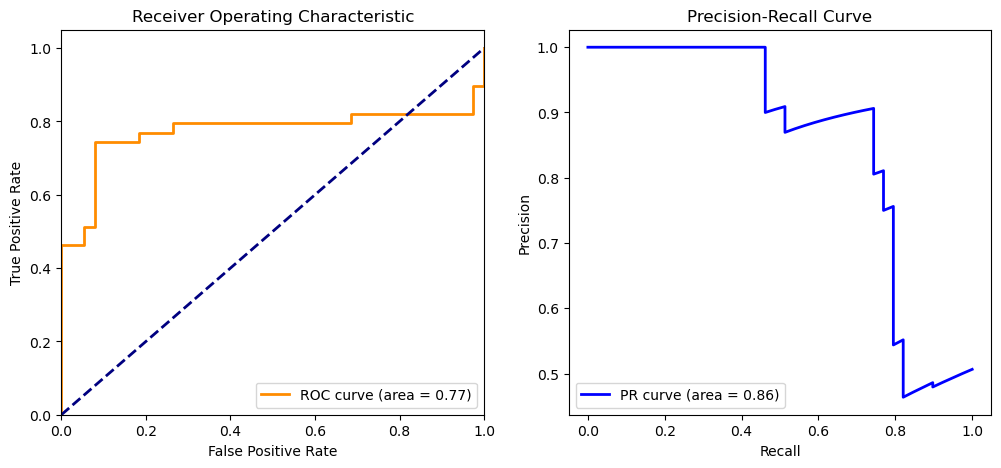


[Training Curves]


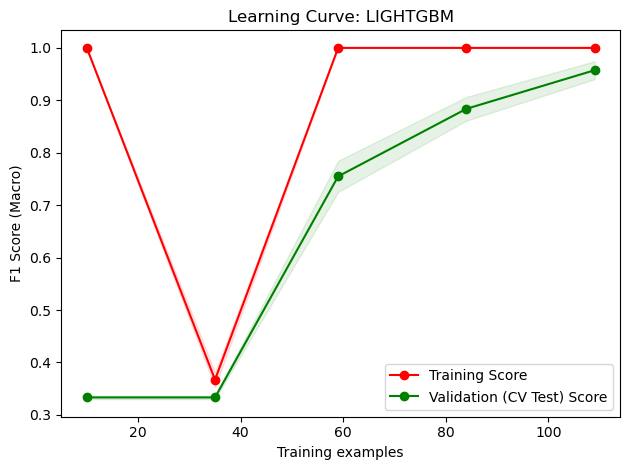

\n[Explainability] Plotting Standard Feature Importances...


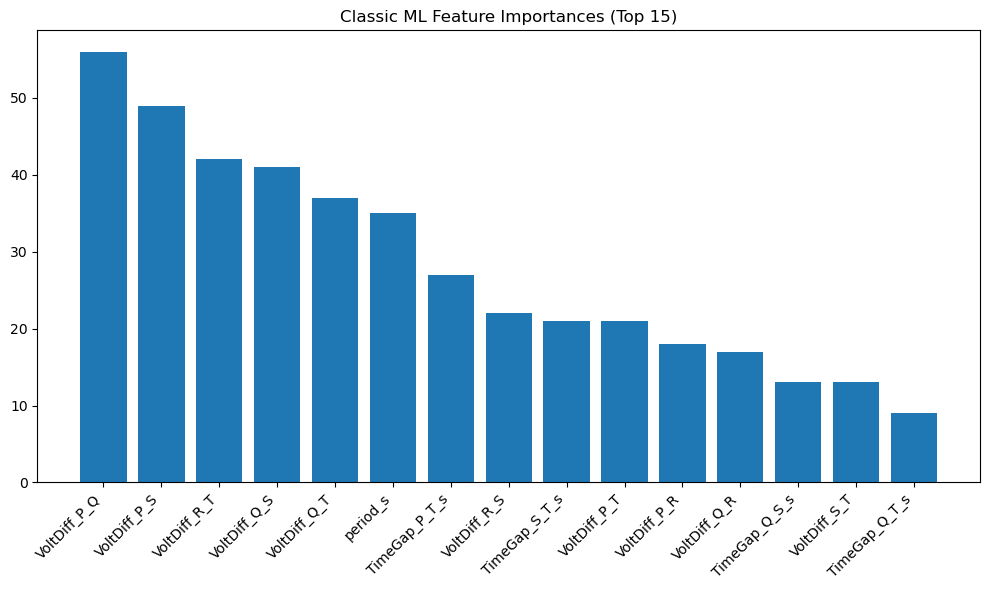

\n==================================================
Running full evaluation on xgboost...

--- Training XGBOOST ---
Skipping xgboost due to error: Model xgboost is not supported or missing dependencies.
\n==================================================
Running full evaluation on random_forest...

--- Training RANDOM_FOREST ---
Best Parameters: {'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__max_depth': 10, 'feature_selection__k': 'all'}

[Test Set Evaluation]
              precision    recall  f1-score   support

           0       0.64      1.00      0.78        38
           1       1.00      0.46      0.63        39

    accuracy                           0.73        77
   macro avg       0.82      0.73      0.71        77
weighted avg       0.82      0.73      0.71        77

TP: 18, TN: 38, FP: 0, FN: 21
PPV (Precision): 1.0000
NPV: 0.6441
MCC: 0.5452
Brier Score Loss: 0.2033 (Lower is better)
PR-AUC: 0.8499


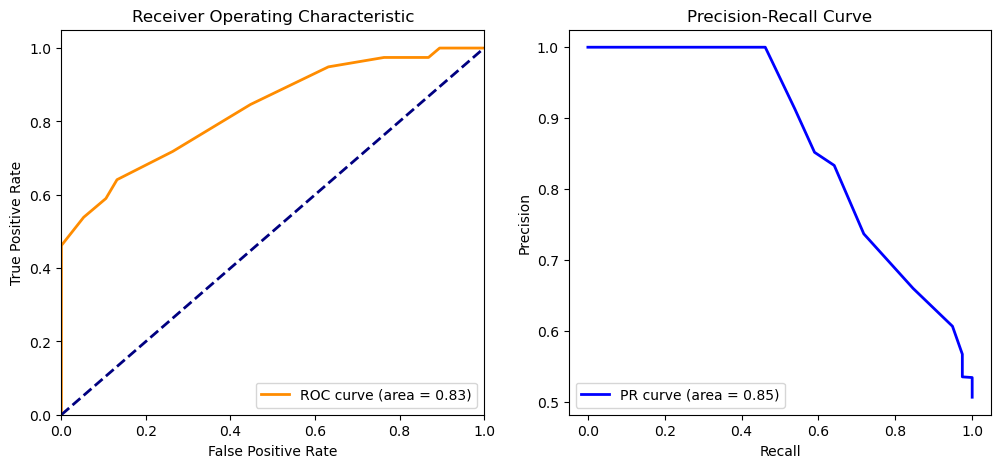


[Training Curves]


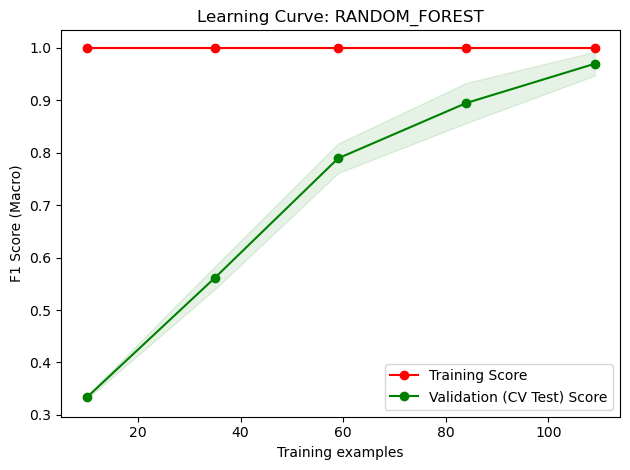

\n[Explainability] Plotting Standard Feature Importances...


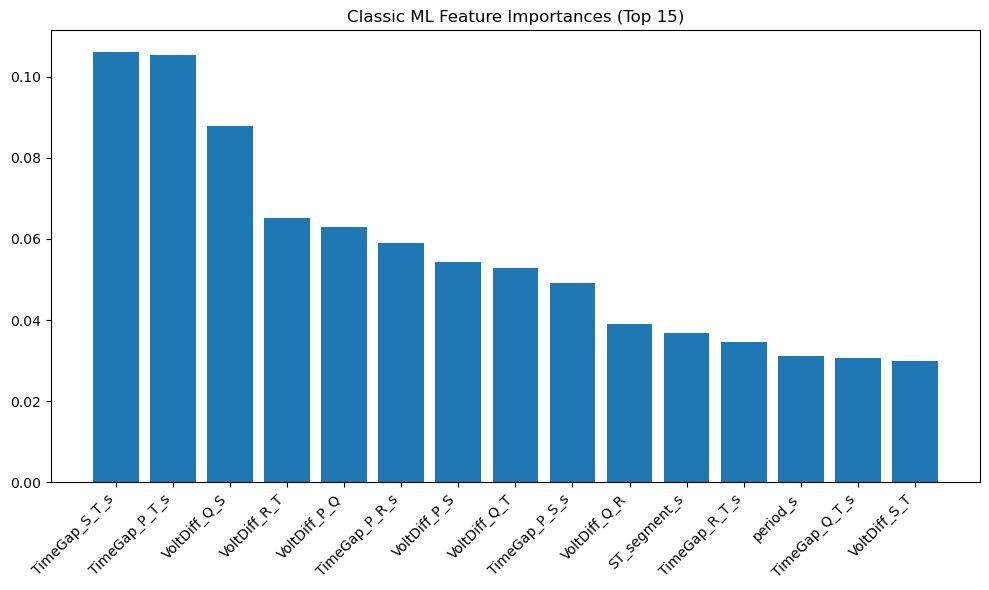

\n==================================================
Running full evaluation on svm...

--- Training SVM ---
Best Parameters: {'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__C': 1, 'feature_selection__k': 'all'}

[Test Set Evaluation]
              precision    recall  f1-score   support

           0       0.36      0.42      0.39        38
           1       0.31      0.26      0.28        39

    accuracy                           0.34        77
   macro avg       0.33      0.34      0.33        77
weighted avg       0.33      0.34      0.33        77

TP: 10, TN: 16, FP: 22, FN: 29
PPV (Precision): 0.3125
NPV: 0.3556
MCC: -0.3272
Brier Score Loss: 0.4141 (Lower is better)
PR-AUC: 0.5024


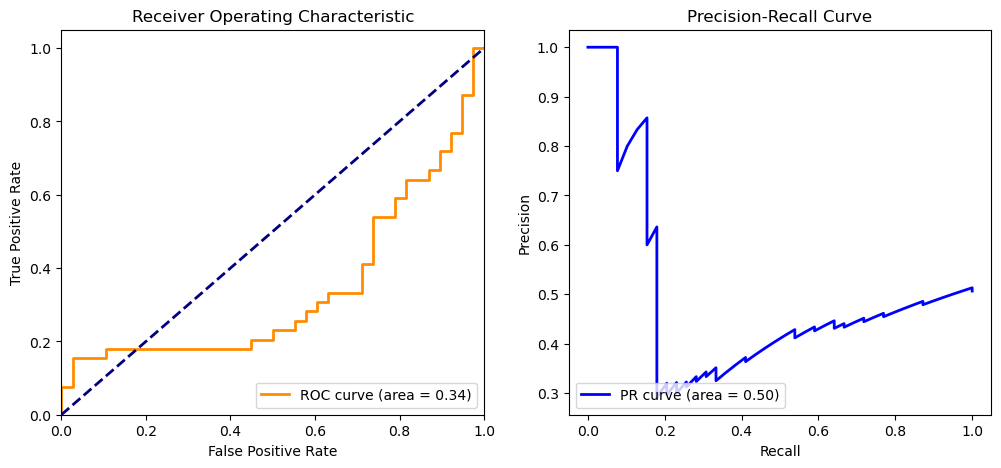


[Training Curves]


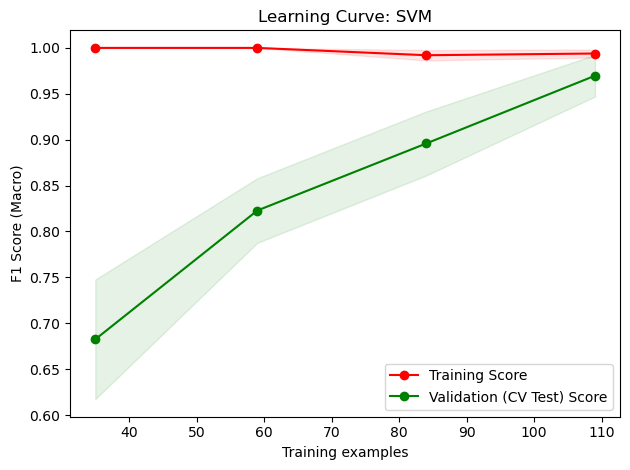

\n--- Benchmark Summary ---
        Model  F1 Score  Accuracy  Inference Time (s)  Train+Eval Time (s)
     lightgbm  0.707692  0.753247            0.013056            12.251176
random_forest  0.631579  0.727273            0.018003            12.471150
          svm  0.281690  0.337662            0.010001             3.133698
\n--- Generating Flagged Segment Comparisons ---


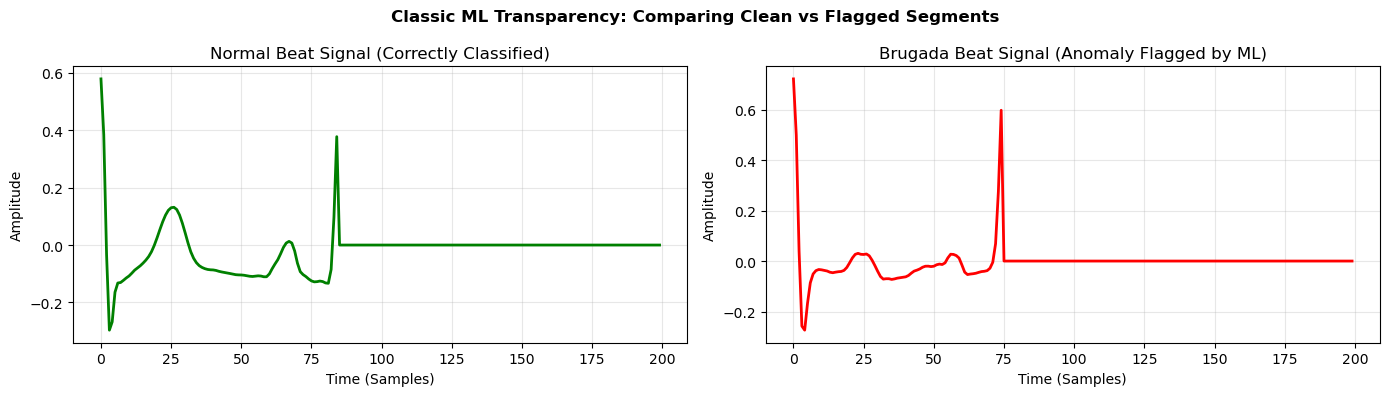

Plotted side-by-side normal vs anomaly segments successfully.


In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit

from ml_pipeline.data_loader import load_wfdb_record, extract_discrete_features, extract_sequence_features
from ml_pipeline.classic_pipeline import train_and_evaluate

def main():
    print("==================================================")
    print("   Classic ML Pipeline (Discrete Beat Features)   ")
    print("==================================================")
    
    # 1. Load Metadata
    metadata_path = "metadata.csv"
    if not os.path.exists(metadata_path):
        print(f"Error: {metadata_path} not found. Please ensure Physionet data is downloaded.")
        return
        
    metadata = pd.read_csv(metadata_path)
    
    # Demonstration subset (10 Brugada, 10 Normal) to make the run fast.
    subset_meta = pd.concat([
        metadata[metadata['brugada'] == 1].head(10),
        metadata[metadata['brugada'] == 0].head(10)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    # 2. Extract Data
    all_features_dfs = []
    all_raw_sequences = [] # We'll store the raw beats here to "catch and plot the problematic segment"
    
    print("Extracting tabular features & raw signals per beat from WFDB records...")
    for idx, row in subset_meta.iterrows():
        patient_id = str(row['patient_id'])
        label = int(row['brugada'])
        
        record_path = f"files/{patient_id}/{patient_id}"
        if not os.path.exists(record_path + ".dat"):
            continue
            
        try:
            df, fs = load_wfdb_record(record_path)
            
            # Extract pd.DataFrame of features (e.g. QRS_duration, VoltDiff_P_T)
            df_patient_feats = extract_discrete_features(df, fs, target_lead='I')
            
            # ALSO Extract raw time-series sequences of Lead I just for plotting comparisons later!
            X_seq = extract_sequence_features(df, fs, target_lead='I', method='pad', target_len=200)
            
            df_patient_feats['label'] = label
            df_patient_feats['patient_id'] = patient_id
            
            all_features_dfs.append(df_patient_feats)
            all_raw_sequences.append(X_seq.squeeze(-1)) # Shape: [num_beats, 200]
        except Exception as e:
            print(f"Skipped patient {patient_id}: {e}")

    # Combine into huge tabular datasets
    df_all = pd.concat(all_features_dfs, ignore_index=True)
    X_seq_all_flat = np.vstack(all_raw_sequences)
    print(f"\\nTotal beats extracted: {len(df_all)}")
    
    # 3. Train / Test Split (Grouped by Patient to Prevent Data Leakage)
    drop_cols = ['label', 'patient_id', 'beat_index', 'normalized_signal']
    X = df_all.drop(columns=[c for c in drop_cols if c in df_all.columns])
    y = df_all['label'].values
    groups = df_all['patient_id'].values
    
    feature_columns = list(X.columns)
    
    # Use GroupShuffleSplit to keep all beats from the same patient in either train or test
    gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
    train_idx, test_idx = next(gss.split(X.values, y, groups))
    
    X_train, X_test = X.values[train_idx], X.values[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    seq_train, seq_test = X_seq_all_flat[train_idx], X_seq_all_flat[test_idx]
    
    print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
    
    # 4. Evaluate Advanced Classic ML Multi-Model Benchmark
    import time
    from sklearn.metrics import f1_score, accuracy_score
    models_to_run = ['lightgbm', 'xgboost', 'random_forest', 'svm']
    
    results = []
    best_overall_model = None
    best_f1 = -1
    
    for model_choice in models_to_run:
        print(f"\\n==================================================")
        print(f"Running full evaluation on {model_choice}...")
        start_time = time.time()
        try:
            current_model = train_and_evaluate(
                X_train, y_train, 
                X_test, y_test, 
                feature_columns=feature_columns, 
                model_name=model_choice, 
                n_iter=5, cv=3 
            )
            inf_start = time.time()
            preds = current_model.predict(X_test)
            inf_end = time.time()
            
            f1 = f1_score(y_test, preds, zero_division=0)
            acc = accuracy_score(y_test, preds)
            
            inf_time = inf_end - inf_start
            total_time = inf_end - start_time
            
            results.append({
                'Model': model_choice,
                'F1 Score': f1,
                'Accuracy': acc,
                'Inference Time (s)': inf_time,
                'Train+Eval Time (s)': total_time
            })
            
            if f1 > best_f1:
                best_f1 = f1
                best_overall_model = current_model
                
        except Exception as e:
            print(f"Skipping {model_choice} due to error: {e}")
            
    print("\\n--- Benchmark Summary ---")
    results_df = pd.DataFrame(results)
    print(results_df.to_string(index=False))
    
    best_model = best_overall_model
    
    if best_model is None:
        print("No models trained successfully. Exiting.")
        return
    
    # 5. Explainability Layer (Catching Flagged Beats vs Normal Beats)
    print("\\n--- Generating Flagged Segment Comparisons ---")
    preds = best_model.predict(X_test)
    
    # Find True Positives (Model caught an Anomaly/Brugada)
    tp_idx = np.where((y_test == 1) & (preds == 1))[0]
    # Find True Negatives (Model confirmed Normal)
    tn_idx = np.where((y_test == 0) & (preds == 0))[0]
    
    if len(tp_idx) > 0 and len(tn_idx) > 0:
        tp_seq = seq_test[tp_idx[0]]
        tn_seq = seq_test[tn_idx[0]]
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        
        axes[0].plot(tn_seq, color='green', lw=2)
        axes[0].set_title("Normal Beat Signal (Correctly Classified)")
        axes[0].set_xlabel("Time (Samples)")
        axes[0].set_ylabel("Amplitude")
        axes[0].grid(True, alpha=0.3)
        
        axes[1].plot(tp_seq, color='red', lw=2)
        axes[1].set_title("Brugada Beat Signal (Anomaly Flagged by ML)")
        axes[1].set_xlabel("Time (Samples)")
        axes[1].set_ylabel("Amplitude")
        axes[1].grid(True, alpha=0.3)
        
        plt.suptitle("Classic ML Transparency: Comparing Clean vs Flagged Segments", fontweight='bold')
        plt.tight_layout()
        plt.show()
        print("Plotted side-by-side normal vs anomaly segments successfully.")

if __name__ == "__main__":
    main()


   Deep Learning Explainability Pipeline (12-Lead CNN)    
\n--- 1. Loading Metadata ---
--- 2. Extracting 12-lead Sequences & Building Dataset ---
Total Beats Extracted: 241
\n--- 3. Preparing PyTorch DataLoaders ---
\n--- 4. Initializing Explainability Model ---
\n--- 5. Training the 12-Lead Attention LSTM Model ---
Epoch 1/3 | Training Loss: 0.6938
Epoch 2/3 | Training Loss: 0.6855
Epoch 3/3 | Training Loss: 0.6842
\n--- 6. Evaluating the Model ---
              precision    recall  f1-score   support

         0.0       0.22      1.00      0.36        11
         1.0       0.00      0.00      0.00        39

    accuracy                           0.22        50
   macro avg       0.11      0.50      0.18        50
weighted avg       0.05      0.22      0.08        50

\n--- 7. EXPLAINABILITY: GRADIENT SALIENCY MAP ---
Evaluating 12-lead beat #0 -> Probability of Brugada: 0.4267
Generating precise Attention heatmap over the identified ECG problematic segment...


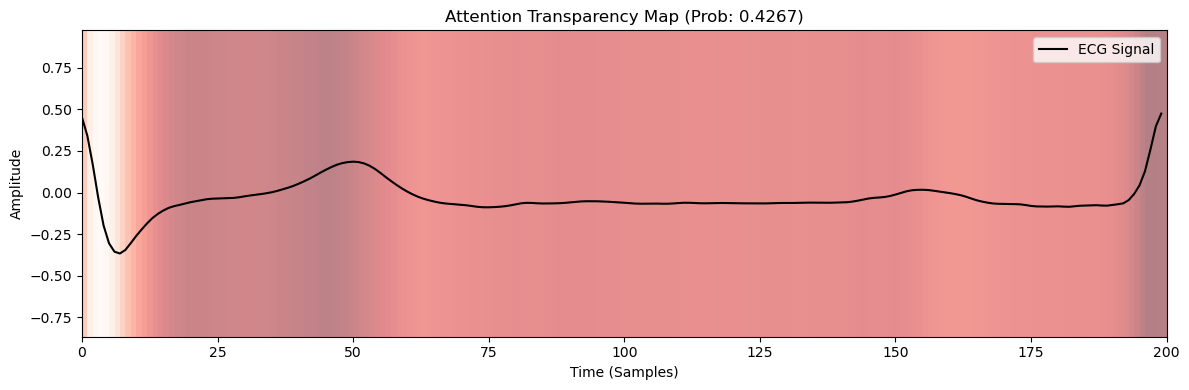

In [20]:
import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import GroupShuffleSplit

# Import our customized pipeline scripts
from ml_pipeline.data_loader import load_wfdb_record, extract_sequence_features
from ml_pipeline.dl_pipeline import ECGAttentionLSTM, ECGSequenceDataset, plot_attention_overlay, train_epoch, evaluate

def main():
    print("==========================================================")
    print("   Deep Learning Explainability Pipeline (12-Lead CNN)    ")
    print("==========================================================")
    print("\\n--- 1. Loading Metadata ---")
    metadata_path = "metadata.csv"
    metadata = pd.read_csv(metadata_path)
    
    # For demonstration, we'll take a subset of 10 Brugada and 10 Normal subjects.
    subset_meta = pd.concat([
        metadata[metadata['brugada'] == 1].head(10),
        metadata[metadata['brugada'] == 0].head(10)
    ]).sample(frac=1, random_state=42).reset_index(drop=True)
    
    X_all = []
    y_all = []
    groups_all = []
    
    print("--- 2. Extracting 12-lead Sequences & Building Dataset ---")
    for idx, row in subset_meta.iterrows():
        patient_id = str(row['patient_id'])
        label = float(row['brugada']) # 1.0 for Brugada, 0.0 for Normal
        
        record_path = f"files/{patient_id}/{patient_id}"
        if not os.path.exists(record_path + ".dat"):
            continue
            
        try:
            df, fs = load_wfdb_record(record_path)
            
            # Extract ALL 12 leads and interpolate to 200 samples per beat
            X_seq = extract_sequence_features(df, fs, use_all_leads=True, method='interpolate', target_len=200)
            
            # X_seq shape is [num_beats, 200, 12].
            X_all.append(X_seq)
            y_all.extend([label] * len(X_seq))
            groups_all.extend([patient_id] * len(X_seq))
        except Exception as e:
            print(f"Skipping patient {patient_id} due to error: {e}")
            
    X_all = np.vstack(X_all) # Shape: [total_beats, 200, 12]
    y_all = np.array(y_all)  # Shape: [total_beats]
    groups_all = np.array(groups_all)
    
    print(f"Total Beats Extracted: {len(X_all)}")
    
    print("\\n--- 3. Preparing PyTorch DataLoaders ---")
    dataset = ECGSequenceDataset(X_all, y_all)
    
    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    train_idx, val_idx = next(gss.split(X_all, y_all, groups=groups_all))
    
    train_ds = Subset(dataset, train_idx)
    val_ds = Subset(dataset, val_idx)
    
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
    
    print("\\n--- 4. Initializing Explainability Model ---")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Input channels = 12 because we are processing the entire multi-lead ECG
    model = ECGAttentionLSTM(input_size=12, hidden_size=64, num_layers=2, num_classes=1).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss() 
    
    print("\\n--- 5. Training the 12-Lead Attention LSTM Model ---")
    epochs = 3
    for epoch in range(epochs):
        loss = train_epoch(model, train_loader, criterion, optimizer, device)
        print(f"Epoch {epoch+1}/{epochs} | Training Loss: {loss:.4f}")
        
    print("\\n--- 6. Evaluating the Model ---")
    evaluate(model, val_loader, device)
    
    print("\\n--- 7. EXPLAINABILITY: GRADIENT SALIENCY MAP ---")
    # Pick a Brugada beat to map gradients onto
    brugada_indices = np.where(y_all == 1)[0]
    
    if len(brugada_indices) > 0:
        sample_idx = brugada_indices[0]
        sample_beat = X_all[sample_idx] # shape: [200, 12]
        
        # PyTorch expects [batch, channels, seq_len]
        sample_tensor = torch.tensor(sample_beat, dtype=torch.float32).unsqueeze(0).transpose(1, 2).to(device)
        
        model.eval()
        with torch.no_grad():
            logits, attn_weights = model(sample_tensor)
            
        prob = torch.sigmoid(logits).item()
        print(f"Evaluating 12-lead beat #{sample_idx} -> Probability of Brugada: {prob:.4f}")
        
        # Plot raw signal mapped against its attention weights
        signal_to_plot = sample_beat[:, 0] 
        attn_to_plot = attn_weights.squeeze(0).cpu().numpy()
        
        print("Generating precise Attention heatmap over the identified ECG problematic segment...")
        plot_attention_overlay(signal_to_plot, attn_to_plot, title=f"Attention Transparency Map (Prob: {prob:.4f})")

if __name__ == "__main__":
    main()


# Experimentation

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from ersi.ersi_val_pipeline import ERSIPipelineValidator

# ==========================================
# 1. PREPARE THE DATA (Lead V1 extraction)
# ==========================================
print("Extracting Lead V1 signals...")
# Assuming 'signals' is the shape (samples, leads) from your previous wfdb cell
# Lead names are typically (I, II, III, aVR, aVL, aVF, V1–V6)
# V1 is usually at index 6 in standard 12-lead
lead_v1_idx = 6 

# IMPORTANT: You need a list of signals from multiple patients here. 
# For demonstration purposes, let's pretend we have a list of patient signals `all_patient_signals` 
# and a list of labels `all_patient_labels` (1 = Brugada, 0 = Control).
# 
# Example placeholder (REPLACE WITH YOUR ACTUAL PATIENT LOOP/LOADER):
#all_patient_signals = [patient_1_v1, patient_2_v1, patient_3_v1, ...]
#all_patient_labels = [1, 0, 1, ...]
# Run benchmark across two subsets
# First, load the metadata to find which patients are Healthy (Normal) vs Brugada
import pandas as pd
import wfdb
import os
metadata = pd.read_csv('metadata.csv')
healthy_patients = metadata[metadata['brugada'] == 0]['patient_id'].astype(str).tolist()
brugada_patients = metadata[metadata['brugada'] == 1]['patient_id'].astype(str).tolist()
healthy_group = []
brugada_group = []


# --- DUMMY DATA FOR NOTEBOOK TESTING ---
# If you don't have the list loaded yet, this will let the cell run to show it works:
#np.random.seed(42)
#all_patient_signals = [np.random.randn(5000) for _ in range(10)] # 10 dummy patients
#all_patient_labels = [1, 0, 1, 0, 1, 0, 1, 0, 1, 0]              # 10 dummy labels
# ---------------------------------------

# ==========================================
# 2. TRAIN / TEST SPLIT (70% / 30%)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    all_patient_signals, 
    all_patient_labels, 
    test_size=0.30, 
    random_state=42,
    stratify=all_patient_labels # Ensures balanced Brugada/Control in train and test
)
print(f"Split complete: {len(X_train)} Train patients, {len(X_test)} Test patients.")

# ==========================================
# 3. INITIALIZE ERSI VALIDATOR
# ==========================================
# fs=500 is common for PhysioNet, adjust to your dataset's actual sampling frequency
validator = ERSIPipelineValidator(fs=500, window_sec=5.0, step_sec=2.5)

# ==========================================
# 4. FEATURE SELECTION ON TRAINING SET
# ==========================================
print("\nExtracting features for Training Set...")
patient_dfs_train = validator.extract_features(X_train)

print("Running Feature Selection (Morphology Top 3)...")
selected_features = validator.feature_selection(patient_dfs_train, y_train, top_k=3)

# ==========================================
# 5. COMPUTE & EVALUATE ON TEST SET
# ==========================================
print("\nExtracting features for Test Set...")
patient_dfs_test = validator.extract_features(X_test)

print("Computing ERSI modes for Test Set...")
df_results_test = validator.compute_ersi_modes(patient_dfs_test, selected_features)

print("Evaluating ERSI (Generating Table & ROC Curve Plots)...")
# Plot=True will generate the matplotlib ROC curves right here in the notebook
df_eval_test = validator.evaluate(df_results_test, y_test, plot=True, title_suffix="(Lead V1)")

display(df_eval_test)

# ==========================================
# 6. OPTIONAL: NOISE SIMULATION TEST
# ==========================================
print("\nRunning Noise Simulation Evaluation (10% Gaussian Noise)...")
df_eval_noisy = validator.simulate_noise_evaluation(X_test, y_test, selected_features, noise_level=0.1)
display(df_eval_noisy)


Extracting Lead V1 signals...
Split complete: 249 Train patients, 107 Test patients.

Extracting features for Training Set...
Running Feature Selection (Morphology Top 3)...

Feature Selection (Training Set) P-values:
Series([], dtype: object)

Selected Top 3 Features: []

Extracting features for Test Set...
Computing ERSI modes for Test Set...
Evaluating ERSI (Generating Table & ROC Curve Plots)...


KeyError: 'AUC'